In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("transformed_crop_yield.csv")
df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_log,Yield_log,Area_log,Fertilizer_log,Pesticide_log
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087,10.945688,0.585610,11.209317,15.764969,10.038164
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435,8.452335,0.536748,8.800566,13.356082,7.629718
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333,3.135494,0.213766,6.680855,11.235277,5.512461
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739,18.658949,8.563896,9.886189,14.441803,8.715119
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909,6.678342,0.351297,7.461640,12.016736,6.291736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000,7.601402,0.405465,8.294300,12.887150,7.057037
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000,8.006701,1.386294,6.908755,11.500863,5.673323
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000,12.996576,0.826366,12.647175,17.202837,11.475999
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667,8.610501,0.016529,12.527239,17.082900,11.356064


In [3]:
df.drop("Production",axis=1,inplace=True)
df


,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production_log,Yield_log,Area_log,Fertilizer_log,Pesticide_log
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087,10.945688,0.585610,11.209317,15.764969,10.038164
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435,8.452335,0.536748,8.800566,13.356082,7.629718
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333,3.135494,0.213766,6.680855,11.235277,5.512461
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739,18.658949,8.563896,9.886189,14.441803,8.715119
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909,6.678342,0.351297,7.461640,12.016736,6.291736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,1498.0,395200.00,1160.00,0.500000,7.601402,0.405465,8.294300,12.887150,7.057037
19685,Wheat,1998,Rabi,Nagaland,1000.0,1498.0,98800.00,290.00,3.000000,8.006701,1.386294,6.908755,11.500863,5.673323
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,1356.2,29586735.11,96373.73,1.285000,12.996576,0.826366,12.647175,17.202837,11.475999
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,1356.2,26242746.82,85481.26,0.016667,8.610501,0.016529,12.527239,17.082900,11.356064


In [4]:
df.drop(["Yield","Area","Fertilizer","Pesticide"],axis=1,inplace=True)
df

,Crop,Crop_Year,Season,State,Annual_Rainfall,Production_log,Yield_log,Area_log,Fertilizer_log,Pesticide_log
0,Arecanut,1997,Whole Year,Assam,2051.4,10.945688,0.585610,11.209317,15.764969,10.038164
1,Arhar/Tur,1997,Kharif,Assam,2051.4,8.452335,0.536748,8.800566,13.356082,7.629718
2,Castor seed,1997,Kharif,Assam,2051.4,3.135494,0.213766,6.680855,11.235277,5.512461
3,Coconut,1997,Whole Year,Assam,2051.4,18.658949,8.563896,9.886189,14.441803,8.715119
4,Cotton(lint),1997,Kharif,Assam,2051.4,6.678342,0.351297,7.461640,12.016736,6.291736
...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,1498.0,7.601402,0.405465,8.294300,12.887150,7.057037
19685,Wheat,1998,Rabi,Nagaland,1498.0,8.006701,1.386294,6.908755,11.500863,5.673323
19686,Maize,1997,Kharif,Jammu and Kashmir,1356.2,12.996576,0.826366,12.647175,17.202837,11.475999
19687,Rice,1997,Kharif,Jammu and Kashmir,1356.2,8.610501,0.016529,12.527239,17.082900,11.356064


In [5]:
df_encoded = pd.get_dummies(df,columns=["Crop","Season","State"],drop_first=True)

In [6]:
df_encoded
df_encoded.to_csv("first_model_data1.csv",index=False)

In [7]:
df_encoded = pd.get_dummies(df, columns=['Crop', 'State', 'Season'], drop_first=True)
df_encoded.shape

(19689, 95)

In [8]:
x = df_encoded.drop("Yield_log",axis=1)
y = df_encoded["Yield_log"]

In [9]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state = 42)
model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
y_pred = model.predict(x_test)


In [12]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean squared Error:",mse)
print("R^2 Score:",r2)

Mean squared Error: 0.02722704688515768
R^2 Score: 0.9783931126188413


In [13]:
import joblib
model = joblib.load("decision_tree_model.pkl")
print("Type:", type(model))
print("n_features_in_:", getattr(model, "n_features_in_", None))
print("feature_names_in_:", getattr(model, "feature_names_in_", None))
print("classes_:", getattr(model, "classes_", None))

Type: <class 'sklearn.tree._classes.DecisionTreeRegressor'>
n_features_in_: 94
feature_names_in_: ['Crop_Year' 'Annual_Rainfall' 'Production_log' 'Area_log'
 'Fertilizer_log' 'Pesticide_log' 'Crop_Arhar/Tur' 'Crop_Bajra'
 'Crop_Banana' 'Crop_Barley' 'Crop_Black pepper' 'Crop_Cardamom'
 'Crop_Cashewnut' 'Crop_Castor seed' 'Crop_Coconut ' 'Crop_Coriander'
 'Crop_Cotton(lint)' 'Crop_Cowpea(Lobia)' 'Crop_Dry chillies'
 'Crop_Garlic' 'Crop_Ginger' 'Crop_Gram' 'Crop_Groundnut' 'Crop_Guar seed'
 'Crop_Horse-gram' 'Crop_Jowar' 'Crop_Jute' 'Crop_Khesari' 'Crop_Linseed'
 'Crop_Maize' 'Crop_Masoor' 'Crop_Mesta' 'Crop_Moong(Green Gram)'
 'Crop_Moth' 'Crop_Niger seed' 'Crop_Oilseeds total' 'Crop_Onion'
 'Crop_Other  Rabi pulses' 'Crop_Other Cereals' 'Crop_Other Kharif pulses'
 'Crop_Other Summer Pulses' 'Crop_Peas & beans (Pulses)' 'Crop_Potato'
 'Crop_Ragi' 'Crop_Rapeseed &Mustard' 'Crop_Rice' 'Crop_Safflower'
 'Crop_Sannhamp' 'Crop_Sesamum' 'Crop_Small millets' 'Crop_Soyabean'
 'Crop_Sugarcane' '

In [15]:
import joblib
joblib.dump(list(x.columns), "model_columns.pkl")
print(f"Saved {len(x.columns)} feature names")

Saved 94 feature names


In [11]:
joblib.dump(model,"decision_tree_model.pkl")

NameError: name 'joblib' is not defined

In [15]:
loaded_model = joblib.load('decision_tree_model.pkl')

In [16]:
from sklearn.tree import plot_tree
from matplotlib.pyplot import rcParams

[Text(0.9712024857251669, 0.99, 'x[14] <= 0.5\nsquared_error = 1.298\nsamples = 15751\nvalue = 1.084'),
 Text(0.9460819739389073, 0.97, 'x[51] <= 0.5\nsquared_error = 0.767\nsamples = 15613\nvalue = 1.017'),
 Text(0.9586422298320371, 0.98, 'True  '),
 Text(0.9190246548871907, 0.95, 'x[42] <= 0.5\nsquared_error = 0.53\nsamples = 15120\nvalue = 0.932'),
 Text(0.8922369366771076, 0.93, 'x[8] <= 0.5\nsquared_error = 0.45\nsamples = 14601\nvalue = 0.877'),
 Text(0.8638962498809982, 0.91, 'x[36] <= 0.5\nsquared_error = 0.386\nsamples = 14412\nvalue = 0.848'),
 Text(0.8254521268177012, 0.89, 'x[54] <= 0.5\nsquared_error = 0.323\nsamples = 14051\nvalue = 0.811'),
 Text(0.7641556225995773, 0.87, 'x[53] <= 0.5\nsquared_error = 0.281\nsamples = 13884\nvalue = 0.79'),
 Text(0.6530261619611705, 0.85, 'x[2] <= 11.096\nsquared_error = 0.248\nsamples = 13668\nvalue = 0.768'),
 Text(0.5951804030146365, 0.83, 'x[20] <= 0.5\nsquared_error = 0.21\nsamples = 9907\nvalue = 0.671'),
 Text(0.582943385438884, 

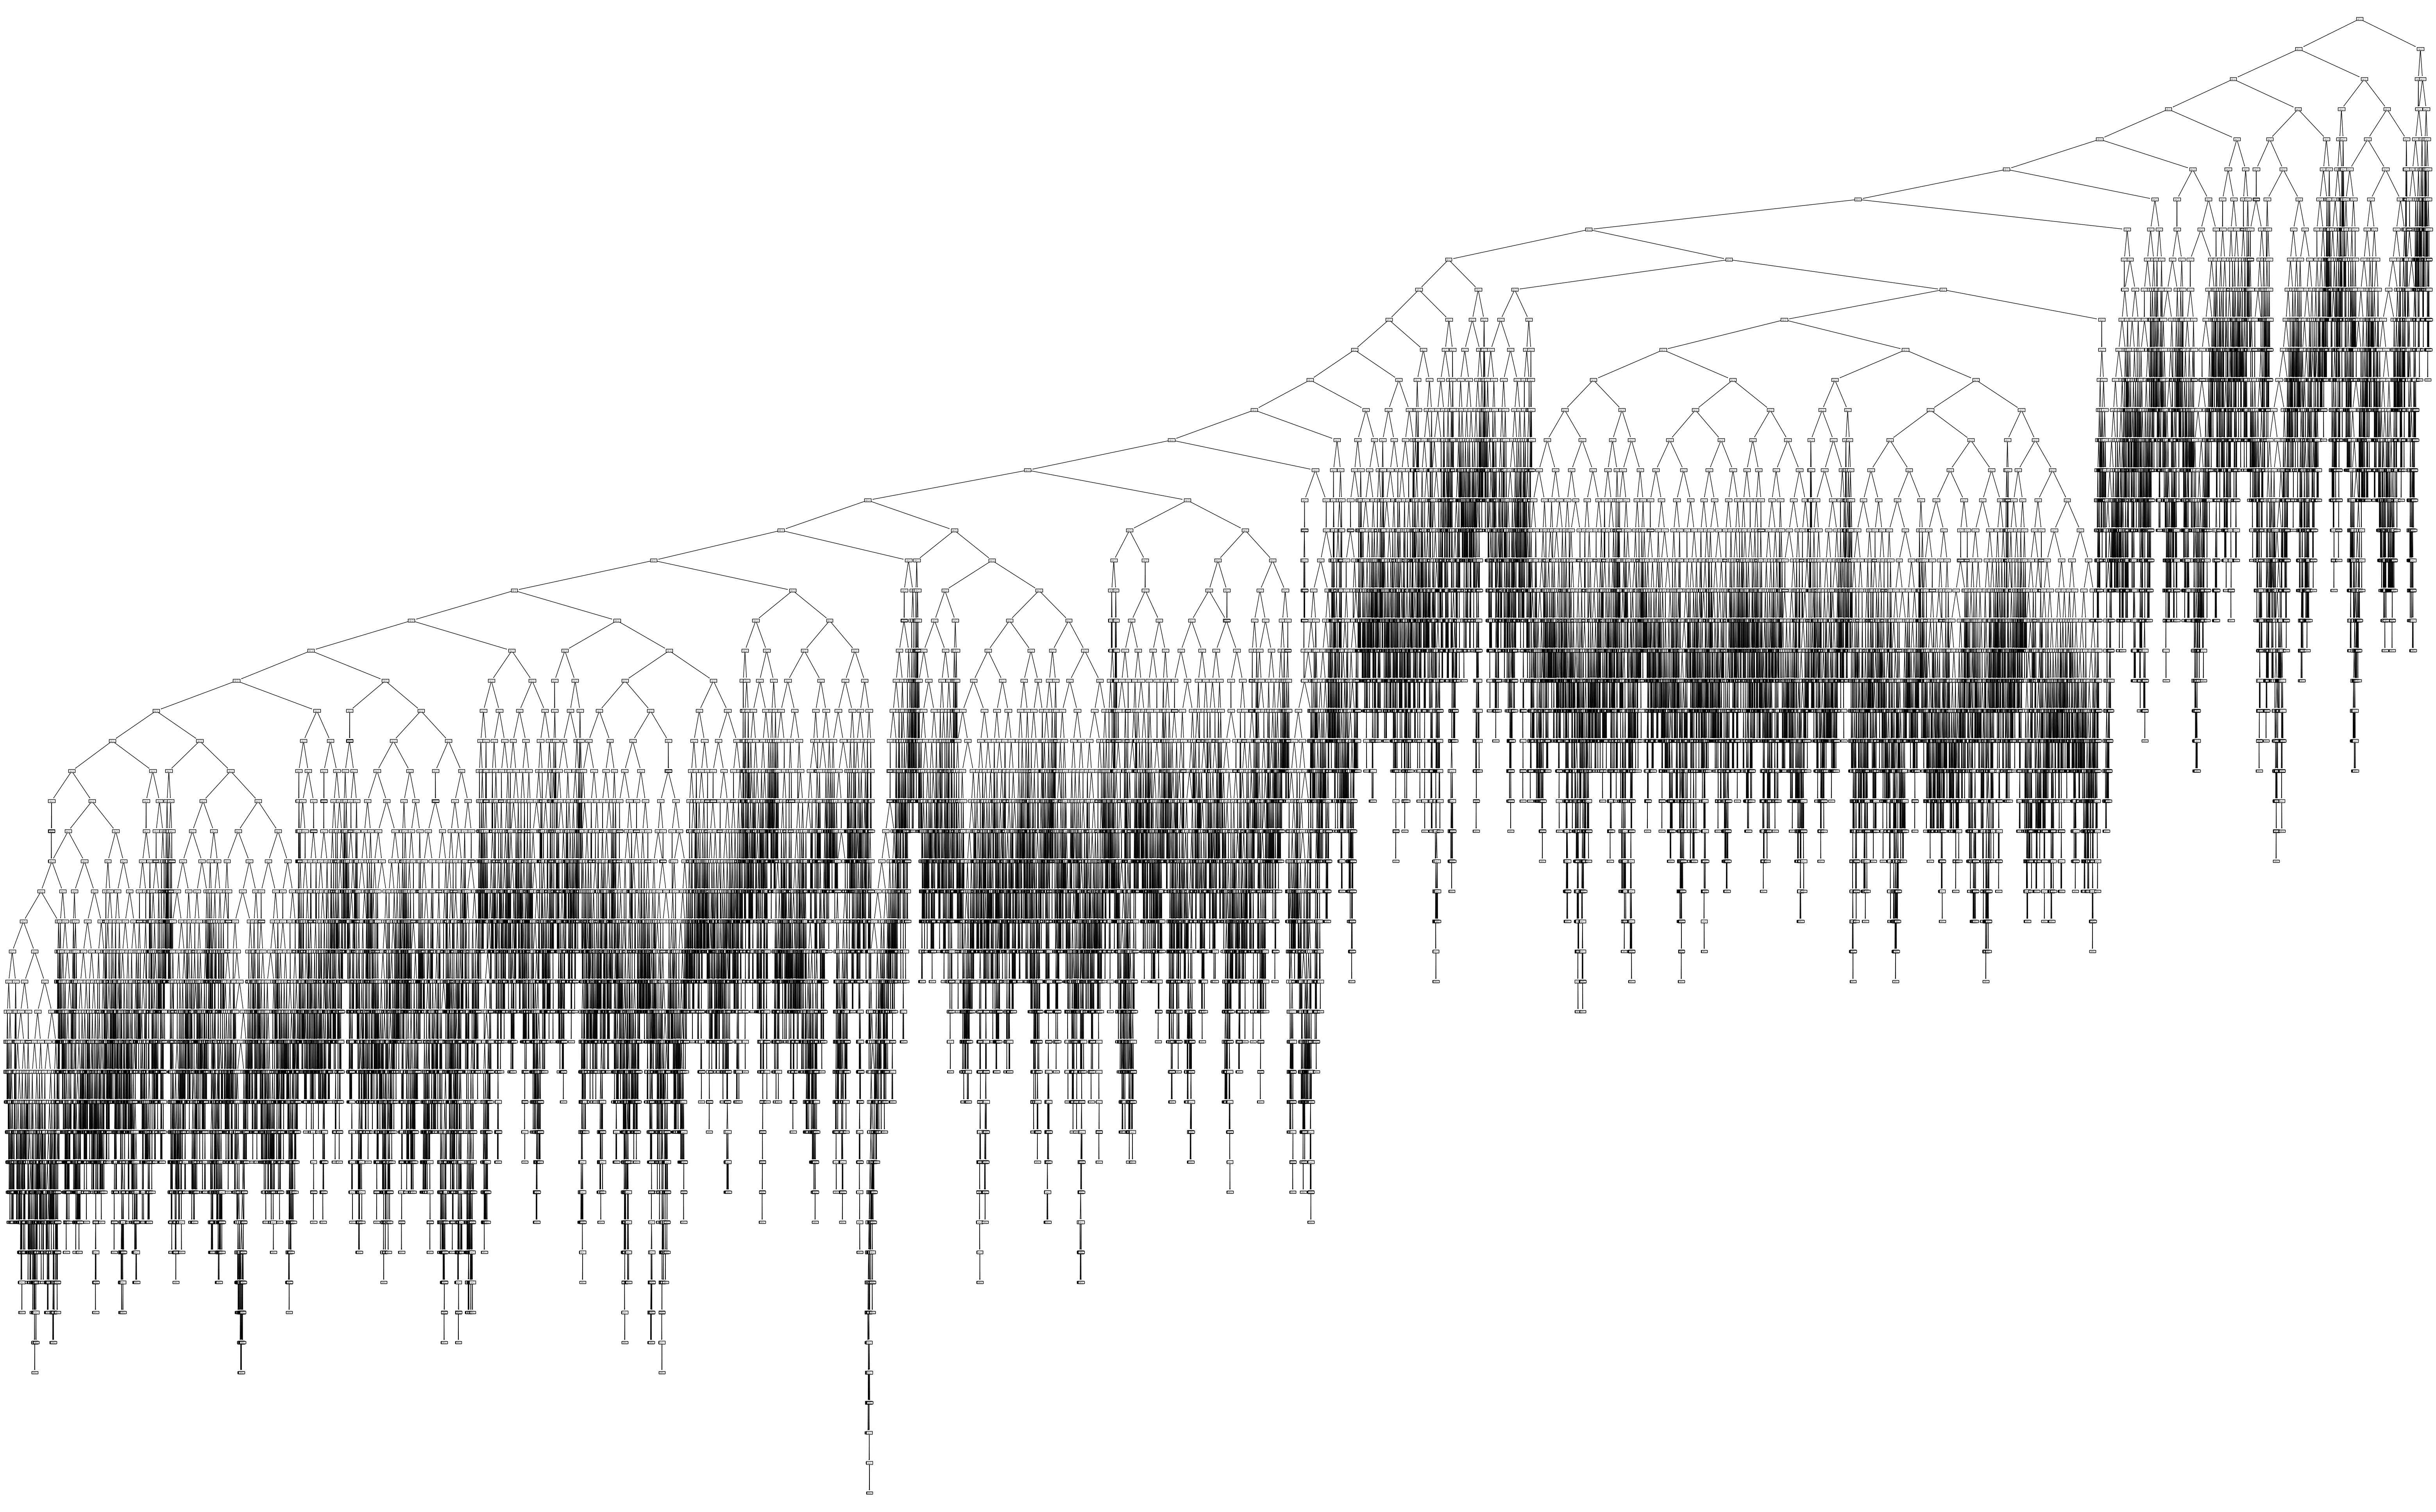

In [17]:
rcParams['figure.figsize']=80,50
plot_tree(model)